In [16]:
"""
combinatorial_deconvolution.ipynb
==================================
4-color ISS barcode deconvolution — deterministic (noiseless) analysis.

All reusable functions live in src/deconvolution.py.
This notebook loads spacers, runs analyses, and generates plots.
"""

import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt

from src.deconvolution import (
    load_spacers_from_csv,
    onehot_4color, pair_sum, k_sum_signal, signal_key, all_pairs,
    collision_stats, collision_stats_k, deconvolution_counts,
    build_lookup_table, deconvolve_signal, generate_imaging_matrix,
    min_L_for_ambig, min_L_to_resolve,
    hamming_distance_prefix, k1_prefix_check,
    sanity_onehot, sanity_ksum, sample_collision_audit,
    plot_ambiguity_vs_L, plot_deconvolution_bars,
    plot_nearest_neighbor_risk, plot_nn_distance_distribution,
    plot_ambig_vs_k, plot_ambig_vs_k_many_L, plot_ambig_vs_L_many_k,
    visualize_pairs_by_within_similarity,
)

# --- Load spacers ---
CSV_PATH = "../data/ops_cloning.csv"
spacers = load_spacers_from_csv(CSV_PATH, spacer_col="Guide with handles")
print(f"Loaded {len(spacers)} spacers")
print(f"First 3: {spacers[:3]}")

Loaded 52 spacers
First 3: ['GGTTCACGCGCAGATGCACGGTTTTAGAGCTAGAAATAG', 'GCGCTCGCGGATCAGCTCCTGTTTTAGAGCTAGAAATAG', 'GCGGTACCAGCGCGACTACGGTTTTAGAGCTAGAAATAG']


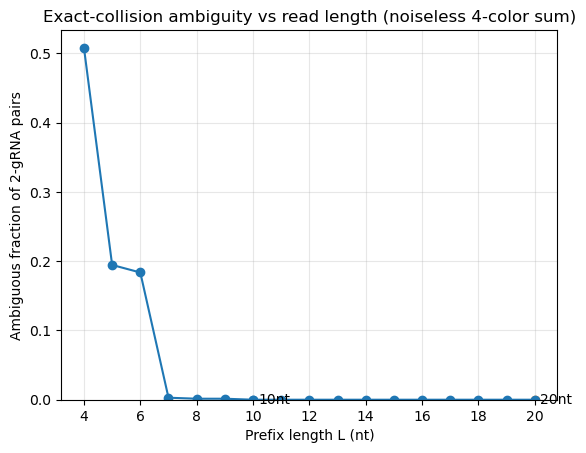

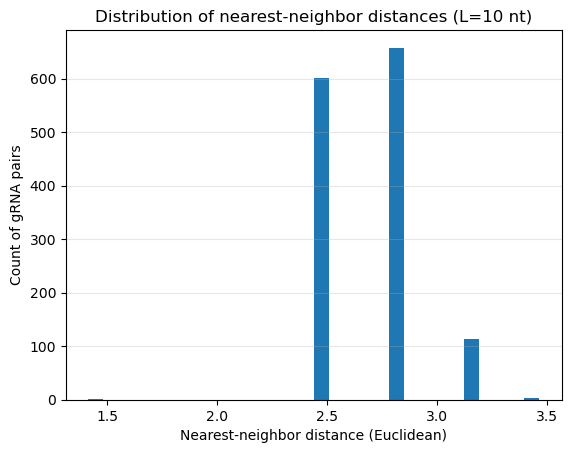

n pairs: 1378
min/median/max: 1.414 / 2.828 / 3.464


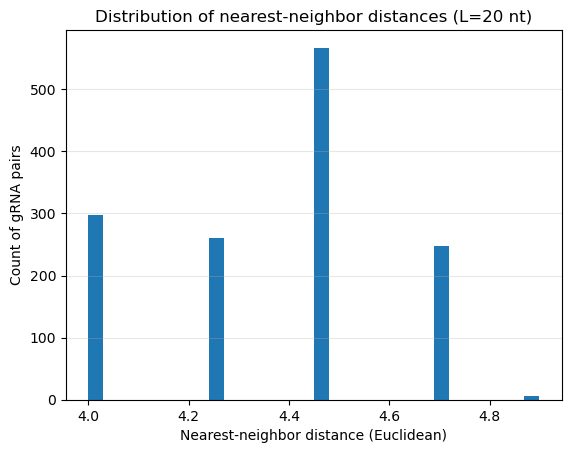

n pairs: 1378
min/median/max: 4.000 / 4.472 / 4.899


In [17]:
# PART 1: Ambiguity vs prefix length (k=2 pairs)
plot_ambiguity_vs_L(spacers, Ls=range(4, 21), mark=(10, 20))

# Nearest-neighbor distance distribution at L=10 and L=20
plot_nn_distance_distribution(spacers, L=10)
plot_nn_distance_distribution(spacers, L=20)


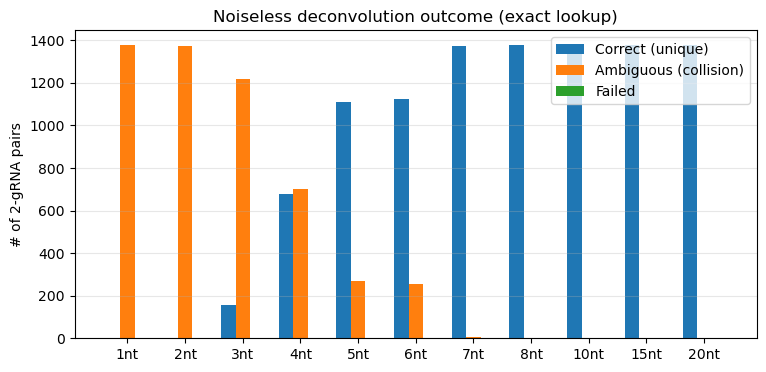

In [21]:
# PART 2: Noiseless deconvolution outcome bars
plot_deconvolution_bars(spacers, Ls=(1, 2, 3, 4, 5, 6, 7, 8, 10, 15, 20))


In [19]:
# PART 3: k-way collision scaling at fixed L values
stats_L4  = [collision_stats_k(spacers, k, L=4)  for k in range(1, 6)]
stats_L20 = [collision_stats_k(spacers, k, L=20) for k in range(1, 6)]

plot_ambig_vs_k(stats_L4,  title="Exact-collision ambiguity vs k (L=4 nt)")
plot_ambig_vs_k(stats_L20, title="Exact-collision ambiguity vs k (L=20 nt)")


KeyboardInterrupt: 

KeyboardInterrupt: 

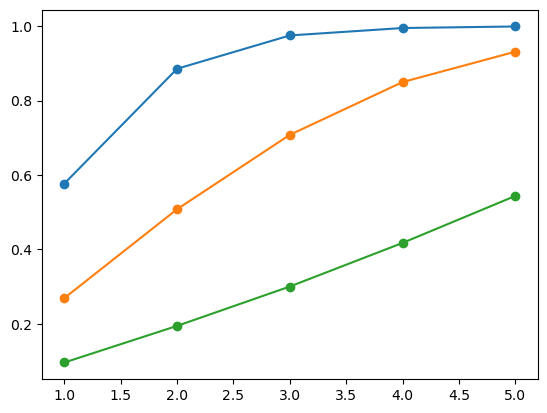

In [20]:
# PART 4: Ambiguity vs k for multiple L values (overlaid)
plot_ambig_vs_k_many_L(spacers, ks=range(1, 6), Ls=(3, 4, 5, 6, 10, 20))


In [6]:
# PART 5: Within-pair similarity (most similar non-self gRNA pairs by Hamming distance)
visualize_pairs_by_within_similarity(spacers, prefix_len=10, n_show=10,
                                     output_path="../outputs/most_similar_nonself_pairs_L10.png")


Saved: ../outputs/most_similar_nonself_pairs_L10.png


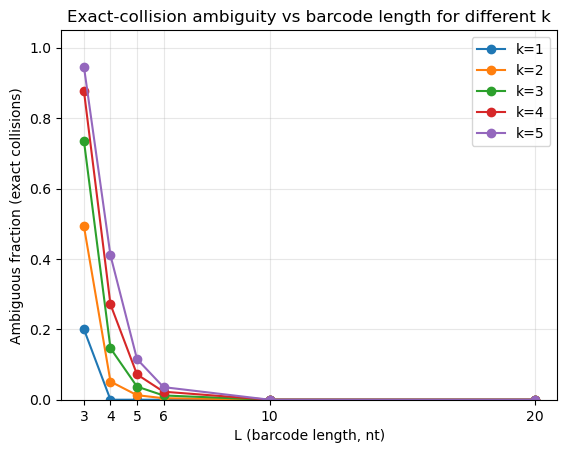

In [7]:
# PART 6: Ambiguity vs L for multiple k values (overlaid)
plot_ambig_vs_L_many_k(spacers, Ls=(3, 4, 5, 6, 10, 20), ks=range(1, 6))


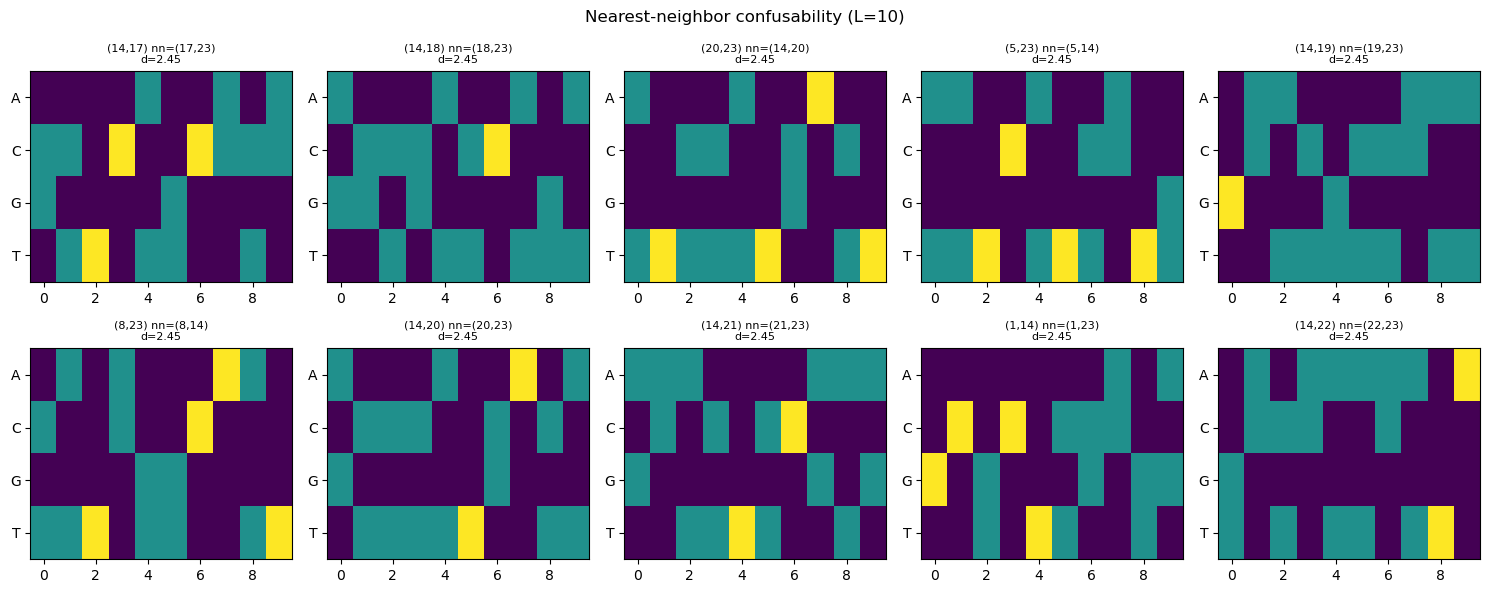

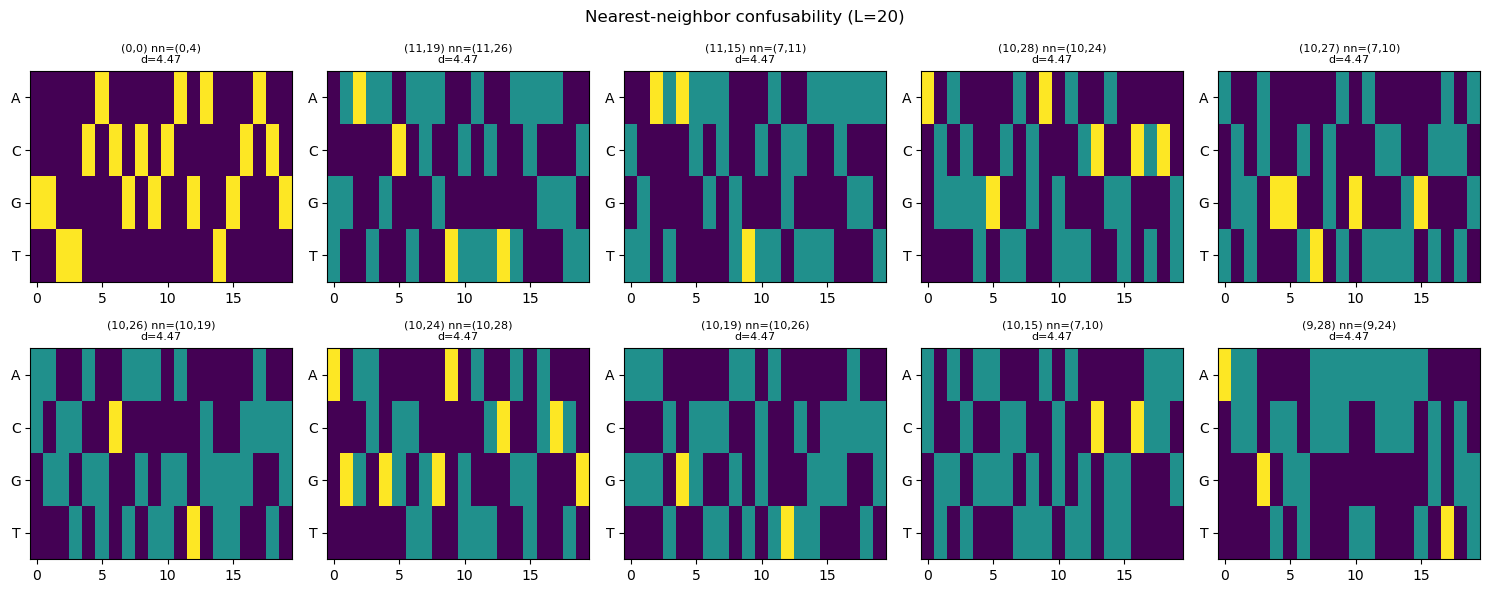

In [8]:
# PART 7: Nearest-neighbor confusability heatmaps
plot_nearest_neighbor_risk(spacers, L=10, n_show=10)
plot_nearest_neighbor_risk(spacers, L=20, n_show=10)


In [9]:
# PART 8: Sanity checks
sanity_onehot(spacers, L=10)
sanity_ksum(spacers, k=6, L=7)


PASS: one-hot encoding checks
PASS: k-sum signal checks


In [10]:
# PART 9: Collision audit (random sampling for k=6, L=7)
sample_collision_audit(spacers, k=6, L=7, n_samples=20000, seed=0)


Sampled combos: 20000, collision groups found: 0


In [11]:
# PART 10: k=1 prefix collision check at L=2 and L=7
k1_prefix_check(spacers, L=2)
k1_prefix_check(spacers, L=7)


k=1, L=2: 9 duplicate groups, 25 collided guides
k=1, L=7: 0 duplicate groups, 0 collided guides


In [12]:
# PART 11: Minimum L to resolve a specific pair of colliding combos
combo1 = (0, 0, 6, 25, 28, 29)
combo2 = (0, 0, 8, 15, 22, 23)
print("min L to resolve:", min_L_to_resolve(spacers, combo1, combo2, L_max=30))


min L to resolve: 1


In [13]:
# PART 12: Minimum L for ambiguous_fraction ≤ 0.1%, by k
for k in range(2, 7):
    Lstar, af = min_L_for_ambig(spacers, k, Ls=range(1, 21), thresh=1e-3)
    print(f"k={k}: min L for ambig≤0.1% = {Lstar}, ambig_fraction = {af:.6f}")


k=2: min L for ambig≤0.1% = 7, ambig_fraction = 0.000000
k=3: min L for ambig≤0.1% = 7, ambig_fraction = 0.000000
k=4: min L for ambig≤0.1% = 7, ambig_fraction = 0.000049
k=5: min L for ambig≤0.1% = 7, ambig_fraction = 0.000216
k=6: min L for ambig≤0.1% = 7, ambig_fraction = 0.000573


In [14]:
# PART 13: Strict vs lenient accuracy at key prefix lengths
print(f"{'L':>4}  {'correct':>8}  {'ambiguous':>10}  {'failed':>7}  {'strict':>8}  {'lenient':>8}")
for L in (5, 6, 7, 8, 10, 15, 20):
    r = deconvolution_counts(spacers, L)
    print(f"{L:>4}  {r['correct']:>8}  {r['ambiguous']:>10}  {r['failed']:>7}"
          f"  {r['accuracy_strict']:>8.3%}  {r['accuracy_lenient']:>8.3%}")


   L   correct   ambiguous   failed    strict   lenient
   5       459           6        0   98.710%  100.000%
   6       463           2        0   99.570%  100.000%
   7       465           0        0  100.000%  100.000%
   8       465           0        0  100.000%  100.000%
  10       465           0        0  100.000%  100.000%
  15       465           0        0  100.000%  100.000%
  20       465           0        0  100.000%  100.000%


In [15]:
# End of deterministic analysis.
# See notebooks/dropout_simulation.ipynb for dropout robustness analysis.
